In [100]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation=None)

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



In [101]:
import numpy as np
import pandas as pd

def compute_scalar_ability(theta_df, a_df, b_series, item_ids, v_unit=None, adjust_difficulty=True, return_v_unit=False):
	"""
	Compute a math-specific ability score from MIRT factors, discriminations, and difficulties.
	
	Args:
		theta_df (pd.DataFrame): Factor scores per test taker (rows = test takers, cols = factors).
		a_df (pd.DataFrame): Discrimination parameters (rows = items, cols = factors).
		b_series (pd.Series): Difficulty parameters (indexed same as a_df rows).
		item_ids (list): List of item IDs (subset of a_df rows) that are math items.
		adjust_difficulty (bool): Whether to weight discriminations by difficulty.
	
	Returns:
		pd.Series: Math ability scores for each test taker.
	"""
	if v_unit is None:
		# 1. Extract discrimination vectors for math items
		A_math = a_df.loc[item_ids].copy()
		b_math = b_series.loc[item_ids]

		# 2. Optionally adjust by difficulty
		if adjust_difficulty:
			weights = 1 / (1 + np.abs(b_math.values))
			A_math = A_math.multiply(weights, axis=0)

		# 3. Compute math direction vector in factor space
		v_unit = A_math.mean(axis=0).values  # vector of length = num_factors
		v_unit = v_unit / np.linalg.norm(v_unit)  # normalize for stability
		print("Mean unit vector: ", v_unit)
		if return_v_unit:
			return v_unit

	else: 
		print("Used pre-computed direction vector.", v_unit)

	# 4. Project each test taker's theta onto v_unit
	theta_matrix = theta_df.values  # shape (n_test_takers, n_factors)
	mmlu_scores = theta_matrix.dot(v_unit)

	return pd.Series(mmlu_scores, index=theta_df.index, name="ability")


In [102]:
conv_dataset = ['math', 'gsm']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

pd.DataFrame(scenario_questions, columns=['question']).to_pickle('../result/mmlu_scenario_questions.pkl')

theta_df = pd.DataFrame(theta, index=models)

a_df = pd.DataFrame(a, index=questions)

b_series = pd.Series(b, index=questions)

In [103]:
import numpy as np
import pandas as pd

def orthogonalize_vector(vector_to_purify, reference_vector):
    """
    Purifies a vector by removing its projection onto a reference vector.
    This is a single step of the Gram-Schmidt process.

    Args:
        vector_to_purify (np.ndarray): The vector you want to purify (e.g., v_math).
        reference_vector (np.ndarray): The vector representing the component to remove (e.g., v_div).

    Returns:
        np.ndarray: The purified, orthogonal vector, normalized to unit length.
    """
    # Ensure vectors are normalized to unit length to start
    vector_to_purify = vector_to_purify / np.linalg.norm(vector_to_purify)
    reference_vector = reference_vector / np.linalg.norm(reference_vector)

    # 1. Calculate the projection of vector_to_purify onto reference_vector
    dot_product = np.dot(vector_to_purify, reference_vector)
    projection = dot_product * reference_vector
    
    # 2. Subtract the projection to get the orthogonal component
    purified_vector = vector_to_purify - projection
    
    # 3. Normalize the final vector to have a length of 1
    purified_vector_normalized = purified_vector / np.linalg.norm(purified_vector)
    
    return purified_vector_normalized

# Verification with Eigenvectors

In [104]:
import pandas as pd
import numpy as np

def get_reference_composite_eigenvector(a_df: pd.DataFrame) -> np.ndarray:
    """
    Calculates the eigenvector for the reference composite from a matrix of 
    multidimensional discrimination parameters.

    This vector corresponds to the largest eigenvalue of the a'a matrix and 
    represents the direction of the dominant unidimensional scale in the 
    multidimensional space.

    Args:
        a_df: A pandas DataFrame with shape (n_items, n_dimensions) 
              containing the 'a' parameters.

    Returns:
        A NumPy array representing the eigenvector of the reference composite.
    """
    # Convert the DataFrame to a NumPy array for matrix operations
    a_matrix = a_df.to_numpy()
    
    # Calculate the a-transpose-a matrix (a'a)
    a_t_a = a_matrix.T @ a_matrix
    
    # Calculate the eigenvalues and eigenvectors of the a'a matrix
    eigenvalues, eigenvectors = np.linalg.eig(a_t_a)
    
    # Find the index of the largest eigenvalue
    max_eigenvalue_index = np.argmax(eigenvalues)
    
    # Select the corresponding eigenvector
    reference_composite_vector = eigenvectors[:, max_eigenvalue_index]
    
    return reference_composite_vector

In [105]:
conv_dataset = ['mmlu']

models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()
inverse_mask = ~items_mask
inverse_questions = resmat.columns[inverse_mask].get_level_values('input.text').to_list()
 
v_unit = compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, return_v_unit=True)
# v_mmlu_unit = get_reference_composite_eigenvector(a_df.loc[scenario_questions])
v_conv_unit = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, return_v_unit=True)

# --- Main Execution ---

v_mmlu_initial = v_conv_unit
v_div_reference = v_unit

# --- Run the Orthogonalization ---
v_mmlu_pure = orthogonalize_vector(v_mmlu_initial, v_div_reference)

print("Purified 'MMLU' Vector (v_mmlu_pure):")
print(np.round(v_mmlu_pure, 4))

# --- Verification ---
# The dot product of the purified vector and the reference vector should be nearly zero.
final_correlation = np.dot(v_mmlu_pure, v_div_reference / np.linalg.norm(v_div_reference))
print(f"\nCorrelation after Orthogonalization (Dot Product): {final_correlation:.4f}")

if np.isclose(final_correlation, 0):
    print("Verification successful: The new math vector is orthogonal to the divergent vector.")
else:
    print("Verification failed.")

Mean unit vector:  [ 0.30202127  0.14775573 -0.226695    0.15416433 -0.01559207  0.02283413
  0.14980485  0.2524245  -0.22012818 -0.20221695 -0.05756592  0.2815708
 -0.40373045 -0.46322274 -0.01374581  0.16289586  0.17039645  0.24038334
  0.24861452]
Mean unit vector:  [-0.33565706 -0.14915645  0.01834318  0.01331665 -0.37393305 -0.25046322
 -0.09584368  0.34311047 -0.23982923 -0.31170118  0.0611814  -0.23872273
  0.18764298 -0.25812575  0.27042544 -0.2807531   0.02545634  0.10138835
  0.2344744 ]
Purified 'MMLU' Vector (v_mmlu_pure):
[-0.3588 -0.1604  0.0351  0.002  -0.3738 -0.2528 -0.1071  0.3255 -0.2243
 -0.2977  0.0656 -0.2601  0.2178 -0.2248  0.2722 -0.2935  0.013   0.084
  0.2168]

Correlation after Orthogonalization (Dot Product): 0.0000
Verification failed.


In [106]:
mmlu_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_mmlu_pure)
div_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, v_unit)
conv_benchmark_mean = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_mmlu_corr = mmlu_scores_pure.corr(div_scores_pure, method='spearman')
print('div_corr', div_mmlu_corr)

conv_mmlu_corr = mmlu_scores_pure.corr(conv_benchmark_mean, method='spearman')
print('conv_corr', conv_mmlu_corr)

Used pre-computed direction vector. [-0.3587582  -0.16041748  0.03505277  0.00202282 -0.37379563 -0.25281683
 -0.10711152  0.32548478 -0.22429849 -0.2976806   0.06557699 -0.26005954
  0.21781972 -0.22477902  0.27216494 -0.2934817   0.01300233  0.08399568
  0.21683574]
Used pre-computed direction vector. [ 0.30202127  0.14775573 -0.226695    0.15416433 -0.01559207  0.02283413
  0.14980485  0.2524245  -0.22012818 -0.20221695 -0.05756592  0.2815708
 -0.40373045 -0.46322274 -0.01374581  0.16289586  0.17039645  0.24038334
  0.24861452]
div_corr -0.2187698260399615
conv_corr 0.9786817105932852


In [107]:
conv_dataset = ['med_qa']


models = resmat.index.to_list()
questions = resmat.columns.get_level_values('input.text').to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(conv_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()
inverse_mask = ~items_mask
inverse_questions = resmat.columns[inverse_mask].get_level_values('input.text').to_list()
 
v_unit = compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, return_v_unit=True)
v_medqa_unit = get_reference_composite_eigenvector(a_df.loc[scenario_questions])


# --- Main Execution ---

v_medqa_initial = v_medqa_unit
v_div_reference = v_unit

# --- Run the Orthogonalization ---
v_medqa_pure = orthogonalize_vector(v_medqa_initial, v_div_reference)

print("Purified Vector:")
print(np.round(-v_medqa_pure, 4))

# --- Verification ---
# The dot product of the purified vector and the reference vector should be nearly zero.
final_correlation = np.dot(-v_medqa_pure, v_div_reference / np.linalg.norm(v_div_reference))
print(f"\nCorrelation after Orthogonalization (Dot Product): {final_correlation:.4f}")

if np.isclose(final_correlation, 0, atol=1e-6):
    print("Verification successful: The new vector is orthogonal to the divergent vector.")
else:
    print("Verification failed.")

Mean unit vector:  [ 0.17750438  0.09307601 -0.20640169  0.14724277 -0.12474029 -0.05205568
  0.11325733  0.3372349  -0.2763865  -0.2841941  -0.03823017  0.19182554
 -0.32208386 -0.5072406   0.0670848   0.0680073   0.16385606  0.2590437
  0.30199188]
Purified Vector:
[-0.3874 -0.2345  0.0939 -0.0164 -0.2591 -0.1369 -0.2921  0.2608 -0.1949
 -0.2537  0.0891 -0.2199  0.3509 -0.1003  0.2361 -0.428  -0.0784 -0.0136
  0.0977]

Correlation after Orthogonalization (Dot Product): -0.0000
Verification successful: The new vector is orthogonal to the divergent vector.


In [108]:
conv_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_medqa_pure)
div_scores_pure= compute_scalar_ability(theta_df, a_df, b_series, inverse_questions, v_unit)
conv_benchmark_mean = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(conv_dataset)]].mean(axis=1)

div_medqa_corr = conv_scores_pure.corr(div_scores_pure, method='spearman')
print('div_corr', div_medqa_corr)

conv_medqa_corr = conv_scores_pure.corr(conv_benchmark_mean, method='spearman')
print('conv_corr', conv_medqa_corr)

Used pre-computed direction vector. [-0.38742042 -0.234502    0.0939404  -0.01635498 -0.2590883  -0.13689576
 -0.29210606  0.2608264  -0.19489136 -0.25366813  0.08914094 -0.21986881
  0.35090986 -0.10027138  0.23608606 -0.42798606 -0.07838911 -0.013649
  0.09771319]
Used pre-computed direction vector. [ 0.17750438  0.09307601 -0.20640169  0.14724277 -0.12474029 -0.05205568
  0.11325733  0.3372349  -0.2763865  -0.2841941  -0.03823017  0.19182554
 -0.32208386 -0.5072406   0.0670848   0.0680073   0.16385606  0.2590437
  0.30199188]
div_corr 0.08087653615094814
conv_corr 0.9451768447607716


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_12656/2332143595.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


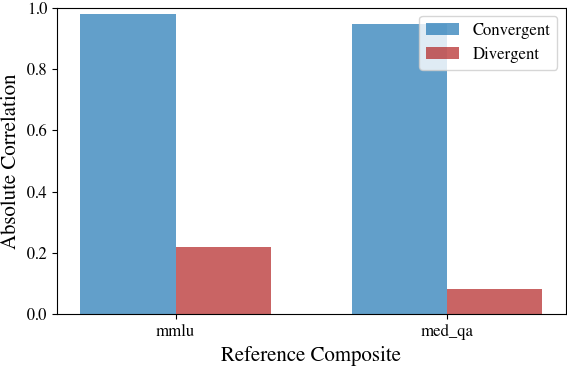

In [109]:
sys.path.append('..') 
import style
import matplotlib.pyplot as plt
plt.rcParams.update(style.rcparams)
import numpy as np

pcs = [f'PC{i+1}' for i in range(2)]
conv_corrs = np.absolute([conv_mmlu_corr, conv_medqa_corr])
div_corrs = np.absolute([div_mmlu_corr, div_medqa_corr])

# Create the two-bar histogram
x = np.arange(len(pcs))  # PC positions
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, conv_corrs, width, label='Convergent', color='C0', alpha=0.7)
bars2 = ax.bar(x + width/2, div_corrs, width, label='Divergent', color='firebrick', alpha=0.7)

# Customize the plot
ax.set_ylabel('Absolute Correlation')
ax.set_xlabel('Reference Composite')
ax.set_xticks(x)
ax.set_xticklabels(['mmlu', 'med_qa'])
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig(f'../result/selective_scale_correlations.pdf')
plt.show()

In [110]:
score_mmlu_pure = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, v_mmlu_pure)
score_medqa_pure = compute_scalar_ability(theta_df, a_df, b_series, scenario_questions, -v_medqa_pure)

score_mmlu_pure.corr(score_medqa_pure, method='spearman')

Used pre-computed direction vector. [-0.3587582  -0.16041748  0.03505277  0.00202282 -0.37379563 -0.25281683
 -0.10711152  0.32548478 -0.22429849 -0.2976806   0.06557699 -0.26005954
  0.21781972 -0.22477902  0.27216494 -0.2934817   0.01300233  0.08399568
  0.21683574]
Used pre-computed direction vector. [-0.38742042 -0.234502    0.0939404  -0.01635498 -0.2590883  -0.13689576
 -0.29210606  0.2608264  -0.19489136 -0.25366813  0.08914094 -0.21986881
  0.35090986 -0.10027138  0.23608606 -0.42798606 -0.07838911 -0.013649
  0.09771319]


np.float64(0.9666648390810901)

In [111]:
mean_mmlu_pure = score_mmlu_pure.mean()
mean_medqa_pure = score_medqa_pure.mean()

v1 = v_mmlu_pure
v2 = v_medqa_pure
mean_v1 = mean_mmlu_pure
mean_v2 = mean_medqa_pure

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_12656/2812432462.py:272: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


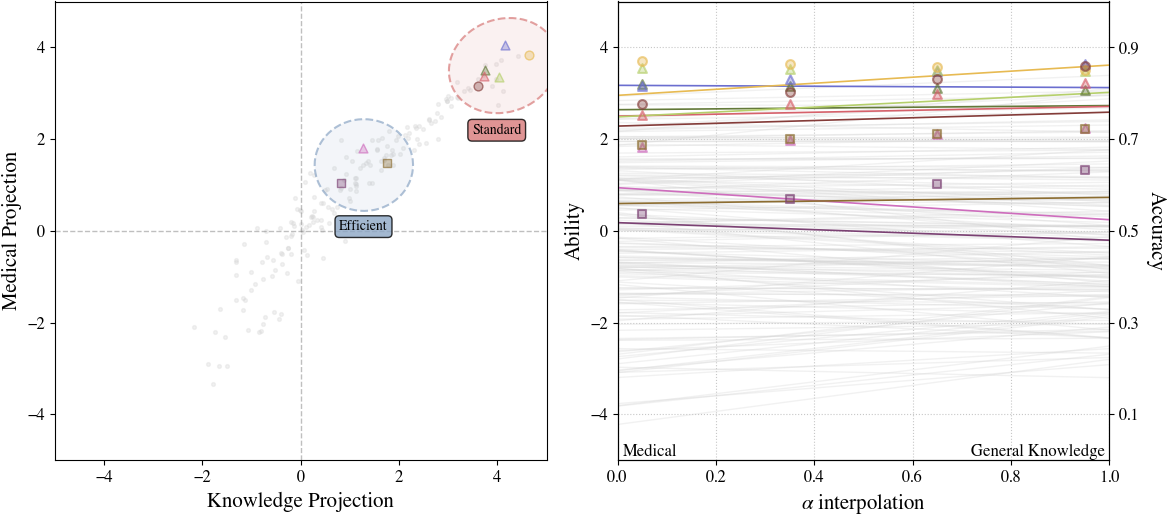

In [145]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D

# Create combined figure with two subplots
# ax1 will now be the LEFT plot, ax2 will be the RIGHT plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# Model classification and colors (shared between both plots)
model_classification = {
    'deepseek-ai/deepseek-v3': 'math',
    'meta/llama-3.1-70b-instruct-turbo': 'math',
    'meta/llama-3.1-405b-instruct-turbo': 'math',
    'anthropic/claude-3-haiku-20240307': 'safety',
    'openai/gpt-4o-2024-08-06': 'general',
    'google/gemini-1.5-pro-002': 'general',
    'qwen/qwen2-72b-instruct': 'math',
    'cohere/command-r': 'safety',
    'databricks/dbrx-instruct': 'math'
}

models_to_name = {
    'deepseek-ai/deepseek-v3': 'DeepSeek v3',
    'meta/llama-3.1-70b-instruct-turbo': 'Llama 3.1 70b Instruct',
    'meta/llama-3.1-405b-instruct-turbo': 'Llama 3.1 405b Instruct',
    'anthropic/claude-3-haiku-20240307': 'Claude 3 Haiku (July 24)',
    'openai/gpt-4o-2024-08-06': 'GPT 4o (June 24)',
    'google/gemini-1.5-pro-002': 'Gemini 1.5 Pro',
    'qwen/qwen2-72b-instruct': 'Qwen 2 72b Instruct',
    'cohere/command-r': 'Command R',
    'databricks/dbrx-instruct': 'DBRX Instruct'
}

models_to_highlight = model_classification.keys()

# Define colors and markers for highlighted models (shared)
highlight_cmap = plt.get_cmap('tab20b')
# Clip the colormap to avoid overly bright/dark colors at the ends
from matplotlib.colors import LinearSegmentedColormap
def clipped_cmap(cmap, minval=0.08, maxval=0.92, n=256):
    return LinearSegmentedColormap.from_list(
        f'clipped({cmap.name})',
        cmap(np.linspace(minval, maxval, n))
    )
highlight_cmap = clipped_cmap(highlight_cmap, minval=0.1)
num_highlight = len(models_to_highlight)
highlight_colors = [highlight_cmap(i / max(num_highlight - 1, 1)) for i in range(num_highlight)]
highlight_color_map = dict(zip(models_to_highlight, highlight_colors))


# ===== LEFT SUBPLOT: SCATTER PLOT (Formerly RIGHT) =====
# Get all models
mmlu_mean_full = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm', 'med_qa'])]].mean(axis=1)
all_indices = mmlu_mean_full.index

# Get PC1 and PC2 scores for all models
all_pc1 = score_mmlu_pure.loc[all_indices]
all_pc2 = score_medqa_pure.loc[all_indices]

# First, plot all models as grey dots (Others)
other_indices = [idx for idx in all_indices if idx not in models_to_highlight]
other_pc1 = score_mmlu_pure.loc[other_indices]
other_pc2 = score_medqa_pure.loc[other_indices]

ax1.scatter(other_pc1, other_pc2,
           color='lightgray',
           marker='.',
           s=30,
           alpha=0.3,
           label='Other Models')

# Plot highlighted models with unique colors and shapes
highlighted_pc1 = score_mmlu_pure.loc[models_to_highlight]
highlighted_pc2 = score_medqa_pure.loc[models_to_highlight]

for model_name, pc1_score, pc2_score in zip(models_to_highlight, highlighted_pc1, highlighted_pc2):
    model_type = model_classification[model_name]

    if model_type == 'math':
        marker_shape = '^'
    elif model_type == 'safety':
        marker_shape = 's'
    elif model_type == 'general':
        marker_shape = 'o'

    color = highlight_color_map[model_name]
    face_color = (*color[:3], 0.35)
    edge_color = (*color[:3], 0.65)

    ax1.scatter(pc1_score, pc2_score,
               color=face_color,
               marker=marker_shape,
               s=40,
               edgecolors=edge_color,
               linewidth=1,
               label=model_name,
               zorder=3)

# Add cluster shading regions
from matplotlib.patches import Ellipse, Circle
import matplotlib.colors as mcolors

# Define cluster groups based on model positions
cluster_A_models = ['deepseek-ai/deepseek-v3', 'meta/llama-3.1-70b-instruct-turbo', 'openai/gpt-4o-2024-08-06', 'google/gemini-1.5-pro-002',
                    'meta/llama-3.1-405b-instruct-turbo', 'qwen/qwen2-72b-instruct']
cluster_B_models = ['cohere/command-r', 'databricks/dbrx-instruct', 'anthropic/claude-3-haiku-20240307']

# Get positions for each cluster
cluster_A_pos = [(score_mmlu_pure.loc[model], score_medqa_pure.loc[model]) for model in cluster_A_models if model in models_to_highlight]
cluster_B_pos = [(score_mmlu_pure.loc[model], score_medqa_pure.loc[model]) for model in cluster_B_models if model in models_to_highlight]

# Define cluster colors (soft pastels)
cluster_colors = {
    'A': '#D77A79',
    'B': '#8CA6C5'
}

# Function to create rotated ellipse around cluster points
def create_cluster_ellipse(positions, ax, color, alpha=0.2, padding=1, rotation=-30, ratio=1):
    if len(positions) < 2:
        # For single points, create a small circle
        if len(positions) == 1:
            x, y = positions[0]
            circle = Circle((x, y), padding*1.2, color=color, alpha=alpha)
            ax.add_patch(circle)
        return

    # Calculate center and span
    positions = np.array(positions)
    # Center is midpoint between most distant x and y coordinates
    center_x = (np.max(positions[:, 0]) + np.min(positions[:, 0])) / 2
    center_y = (np.max(positions[:, 1]) + np.min(positions[:, 1])) / 2

    # Calculate width and height with moderate padding
    width = (np.max(positions[:, 0]) - np.min(positions[:, 0]))*ratio + 2*padding
    height = (np.max(positions[:, 1]) - np.min(positions[:, 1])) + 2*padding

    # Ensure minimum size but not too large
    width = max(width, 2.0)
    height = max(height, 2.0)
    color = mcolors.to_rgba(color)

    face_color = (*color[:3], 0.1)
    edge_color = (*color[:3], 0.7)

    # Create rotated ellipse
    ellipse = Ellipse(
        (center_x, center_y), width, height,
        angle=rotation,
        facecolor=face_color,
        edgecolor=edge_color,
        zorder=1,
        linewidth=1.5,
        linestyle='--'
    )
    ax.add_patch(ellipse)

# Add cluster ellipses and labels
if cluster_A_pos:
    create_cluster_ellipse(cluster_A_pos, ax1, cluster_colors['A'], padding=0.5, rotation=30, ratio=1.25)
    # Add label for cluster A
    center_x = np.mean([pos[0] for pos in cluster_A_pos])
    center_y = np.mean([pos[1] for pos in cluster_A_pos])
    ax1.text(center_x, center_y - 1.5, 'Standard', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['A'], alpha=0.8))

if cluster_B_pos:
    create_cluster_ellipse(cluster_B_pos, ax1, cluster_colors['B'], padding=0)
    # Add label for cluster B
    center_x = np.mean([pos[0] for pos in cluster_B_pos])
    center_y = np.mean([pos[1] for pos in cluster_B_pos])
    ax1.text(center_x, center_y - 1.5, 'Efficient', ha='center', va='bottom',
             fontweight='bold', fontsize=10, zorder=50,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=cluster_colors['B'], alpha=0.8))

# Add quadrant lines
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Customize the left plot
ax1.set_xlabel('Knowledge Projection')
ax1.set_ylabel('Medical Projection')
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)


# ===== RIGHT SUBPLOT: SELECTIVE SCALE ACCURACY =====
p_dim = len(theta)

# In your text labels, "Medical" corresponds to the airbench vector
avg_mmlu_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['mmlu'])]].mean(axis=1)
avg_medical_acc = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['med_qa'])]].mean(axis=1)

# Calculate and Scale Data
a_values = np.linspace(0, 1, 50)
p_matrix = np.zeros((p_dim, len(a_values)))
for i, model_theta in enumerate(theta):
    for j, a in enumerate(a_values):
        p = model_theta @ (a * v_mmlu_pure + (1 - a) * -v_medqa_pure) - (a * mean_mmlu_pure + (1 - a) * mean_medqa_pure)
        p_matrix[i, j] = p

scaler = MinMaxScaler(feature_range=(-5, 5))
scaler.fit([[0], [1]])
def scale_accuracy(accuracy):
    return scaler.transform(np.array(accuracy).reshape(-1, 1)).flatten() if np.ndim(accuracy) else scaler.transform([[accuracy]])[0, 0]

# Plot the lines
for i in range(p_matrix.shape[0]):
    model_name = theta_df.index[i]
    if model_name in models_to_highlight:
        color = highlight_color_map[model_name]
        ax2.plot(a_values, p_matrix[i, :], linewidth=1.2, label=models_to_name.get(model_name, model_name), alpha=1.0, color=color, zorder=10)

        mmlu_acc = avg_mmlu_acc.get(model_name, 0)
        medical_acc = avg_medical_acc.get(model_name, 0)

        scaled_mmlu = scale_accuracy(mmlu_acc)
        scaled_medical = scale_accuracy(medical_acc)

        x_dots = np.linspace(0.05, 0.95, 4)
        y_dots = x_dots * scaled_mmlu + (1 - x_dots) * scaled_medical

        # Determine marker shape based on classification
        model_type = model_classification.get(model_name)
        if model_type == 'math':
            marker_shape = '^'
        elif model_type == 'safety':
            marker_shape = 's'
        elif model_type == 'general':
            marker_shape = 'o'

        face_color = (*color[:3], 0.35)
        edge_color = (*color[:3], 0.65)

        ax2.scatter(x_dots, y_dots,
                   facecolor=face_color,
                   edgecolor=edge_color,
                   s=40,
                   linewidths=1.5,
                   marker=marker_shape,
                   zorder=11)
    else:
        ax2.plot(a_values, p_matrix[i, :], color='lightgray', alpha=0.3, lw=1)

# Add right y-axis for scaled average accuracy score
ax2_right = ax2.twinx()
ax2_right.set_ylim(-5, 5)
ax2_right.set_ylabel('Accuracy', rotation=270, va='bottom')
ax2_right.tick_params(axis='y')

# Set right y-axis to have the same ticks as the left: -4, -2, 0, 2, 4
left_ticks = np.array([-4, -2, 0, 2, 4])
# Inverse transform to get the corresponding accuracy values for these ticks
acc_ticks = scaler.inverse_transform(left_ticks.reshape(-1, 1)).flatten()
ax2_right.set_yticks(left_ticks)
ax2_right.set_yticklabels([f"{x:.1f}" for x in acc_ticks])

# Format the right plot
ax2.set_xlim(0, 1)
ax2.set_ylim(-5, 5)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.text(0.01, ax2.get_ylim()[0], 'Medical', va='bottom')
ax2.text(0.99, ax2.get_ylim()[0], 'General Knowledge', ha='right', va='bottom')
ax2.set_xlabel(r'$\alpha$ interpolation')
ax2.set_ylabel('Ability')



plt.tight_layout()
plt.savefig('../result/combined_mmlu_medical_analysis.pdf', bbox_inches='tight')
plt.show()

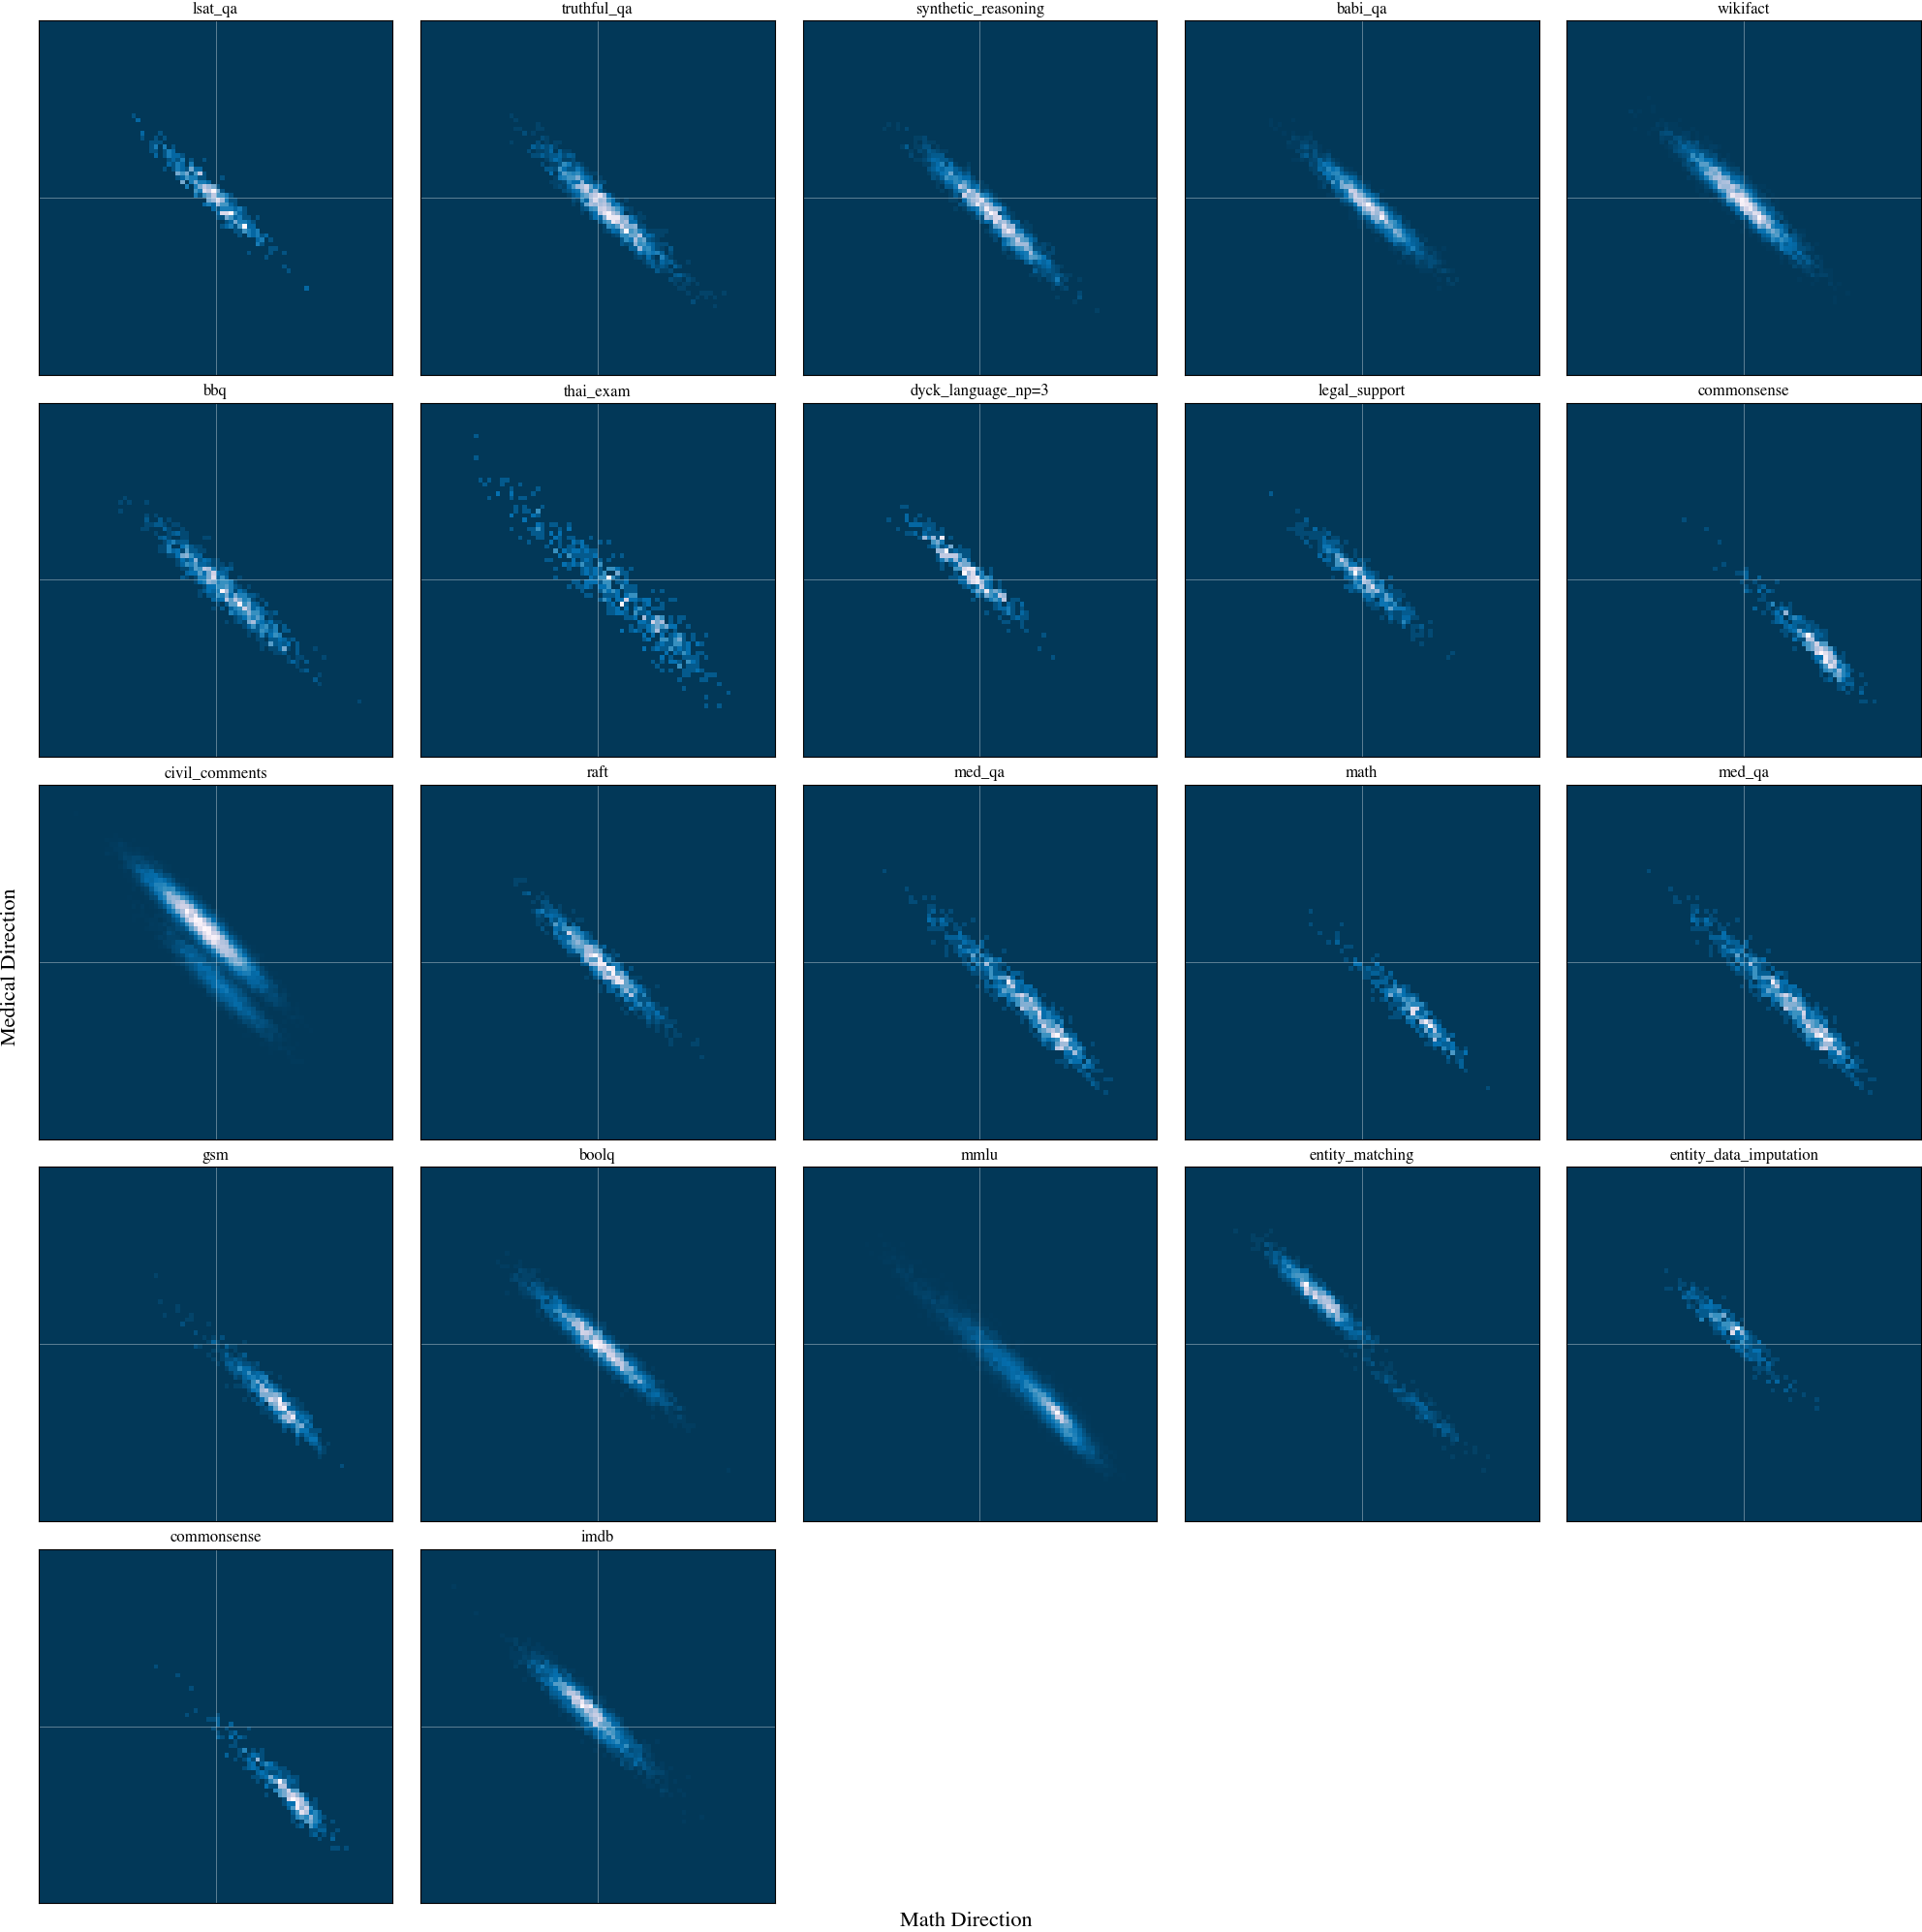

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scenarios = [
    'lsat_qa', 'truthful_qa', 'synthetic_reasoning', 'babi_qa', 'wikifact',
    'bbq', 'thai_exam', 'dyck_language_np=3', 'legal_support',
    'commonsense', 'civil_comments', 'raft', 'med_qa', 'math',
    'med_qa', 'gsm', 'boolq', 'mmlu', 'entity_matching',
    'entity_data_imputation', 'commonsense', 'imdb'
]

# --- 1. Orthonormalize v1 and v2 (One-time calculation) ---
v1 = v_mmlu_pure
v2 = v_medqa_pure
# --- 2. Pre-calculate all projections and find global axis limits ---
all_coords = {}
global_max_lim = 0

for scenario in scenarios:
    current_scenario_list = [scenario]
    items_mask = resmat.columns.get_level_values('scenario').isin(current_scenario_list)
    scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

    if not scenario_questions:
        print(f"Warning: No data found for scenario '{scenario}'. Skipping.")
        continue
    
    scenario_vectors = a_df.loc[scenario_questions].to_numpy()

    coords_x = scenario_vectors @ v1
    coords_y = scenario_vectors @ v2
    all_coords[scenario] = (coords_x, coords_y)
    
    if coords_x.size > 0 and coords_y.size > 0:
        local_max = max(np.abs(coords_x).max(), np.abs(coords_y).max())
        if local_max > global_max_lim:
            global_max_lim = local_max

axis_limit = global_max_lim * 1.15

# --- 3. Create the Combined Heatmap Plot ---
bins = 80 # The resolution of the heatmap grid
hist_range = [[-axis_limit, axis_limit], [-axis_limit, axis_limit]]

n_scenarios = len(scenarios)
n_cols = 5
n_rows = int(np.ceil(n_scenarios / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    
    if scenario not in all_coords:
        ax.set_title(f"{scenario}\n(No Data)", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
        
    coords_x, coords_y = all_coords[scenario]
    
    # --- EDITED PART ---
    # The 'vmax' parameter has been removed.
    # Now, each heatmap's color scale is relative to its own data.
    ax.hist2d(coords_x, coords_y, bins=bins, range=hist_range, cmap='PuBu_r')
    
    ax.set_title(scenario, fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='white', lw=0.5, alpha=0.5)
    ax.axvline(0, color='white', lw=0.5, alpha=0.5)
    ax.set_facecolor('black')
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)

# --- 4. Final Formatting ---
# Hide any unused subplots
for i in range(len(scenarios), len(axes_flat)):
    axes_flat[i].set_visible(False)

# Add shared labels and title
fig.supxlabel("Math Direction", fontsize=16)
fig.supylabel("Medical Direction", fontsize=16)

# --- EDITED PART ---
# The colorbar creation code has been removed.
plt.savefig(f'../result/selective_scale_item_loadings_full.pdf')
plt.show()

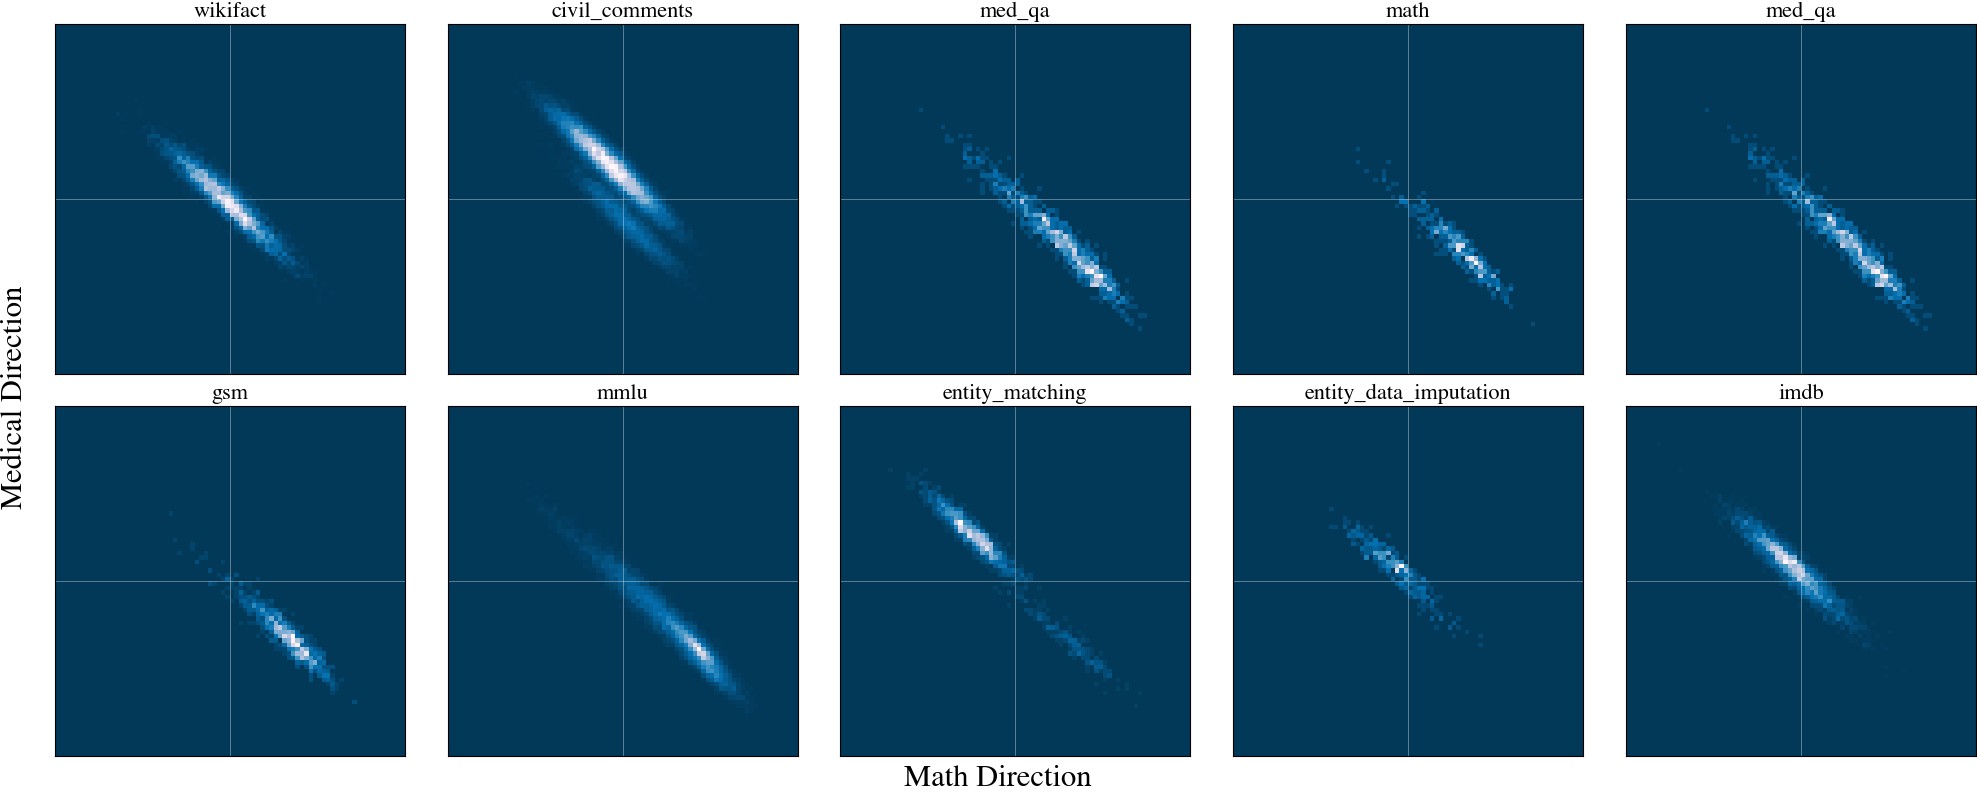

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scenarios = [
    'wikifact',
    'civil_comments', 'med_qa', 'math',
    'med_qa', 'gsm', 'mmlu', 'entity_matching',
    'entity_data_imputation', 'imdb'
]

# --- 1. Orthonormalize v1 and v2 (One-time calculation) ---
v1 = v_mmlu_pure
v2 = v_medqa_pure
# --- 2. Pre-calculate all projections and find global axis limits ---
all_coords = {}
global_max_lim = 0

for scenario in scenarios:
    current_scenario_list = [scenario]
    items_mask = resmat.columns.get_level_values('scenario').isin(current_scenario_list)
    scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

    if not scenario_questions:
        print(f"Warning: No data found for scenario '{scenario}'. Skipping.")
        continue
    
    scenario_vectors = a_df.loc[scenario_questions].to_numpy()

    coords_x = scenario_vectors @ v1
    coords_y = scenario_vectors @ v2
    all_coords[scenario] = (coords_x, coords_y)
    
    if coords_x.size > 0 and coords_y.size > 0:
        local_max = max(np.abs(coords_x).max(), np.abs(coords_y).max())
        if local_max > global_max_lim:
            global_max_lim = local_max

axis_limit = global_max_lim * 1.15

# --- 3. Create the Combined Heatmap Plot ---
bins = 80 # The resolution of the heatmap grid
hist_range = [[-axis_limit, axis_limit], [-axis_limit, axis_limit]]

n_scenarios = len(scenarios)
n_cols = 5
n_rows = int(np.ceil(n_scenarios / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes_flat = axes.flatten()

for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    
    if scenario not in all_coords:
        ax.set_title(f"{scenario}\n(No Data)", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
        
    coords_x, coords_y = all_coords[scenario]
    
    # --- EDITED PART ---
    # The 'vmax' parameter has been removed.
    # Now, each heatmap's color scale is relative to its own data.
    ax.hist2d(coords_x, coords_y, bins=bins, range=hist_range, cmap='PuBu_r')
    
    ax.set_title(scenario, fontsize=16)
    ax.set_aspect('equal', adjustable='box')
    ax.axhline(0, color='white', lw=0.5, alpha=0.5)
    ax.axvline(0, color='white', lw=0.5, alpha=0.5)
    ax.set_facecolor('black')
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)

# --- 4. Final Formatting ---
# Hide any unused subplots
for i in range(len(scenarios), len(axes_flat)):
    axes_flat[i].set_visible(False)

# Add shared labels and title
fig.supxlabel("Math Direction", fontsize=22)
fig.supylabel("Medical Direction", fontsize=22)

# --- EDITED PART ---
# The colorbar creation code has been removed.
plt.savefig(f'../result/selective_scale_item_loadings.pdf')
plt.show()

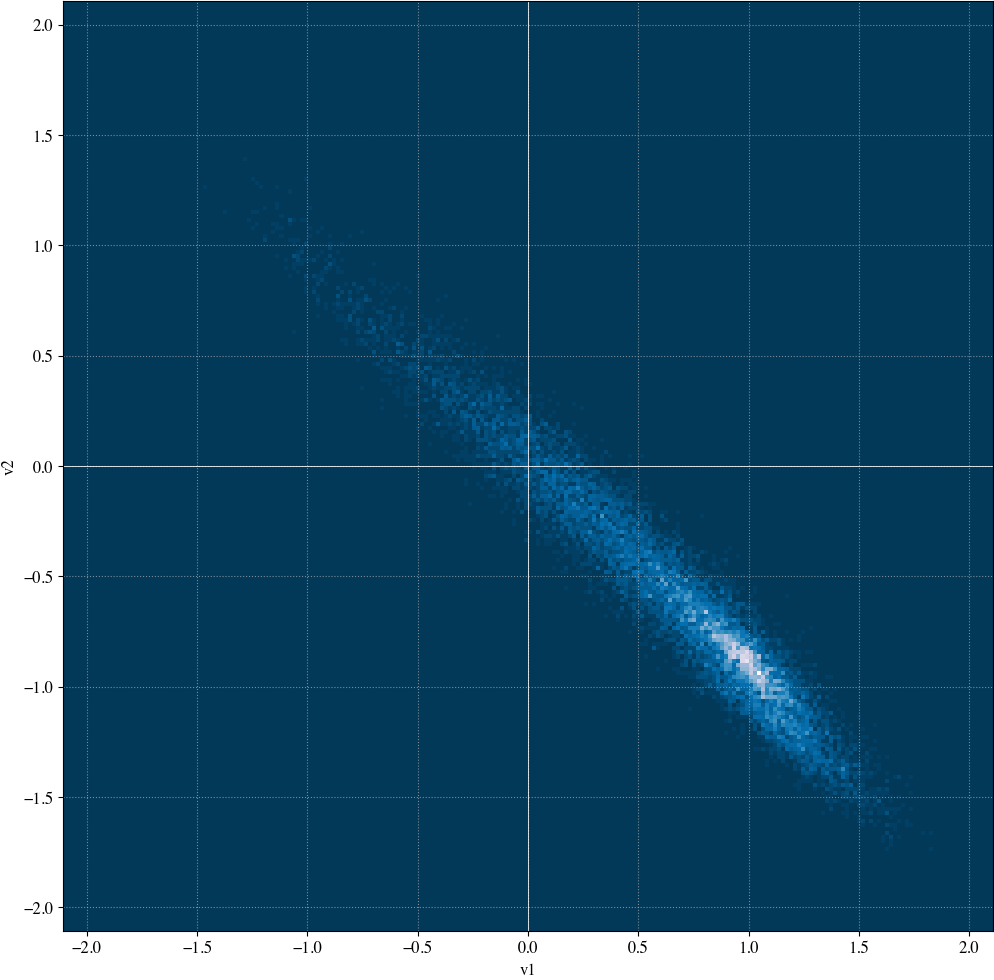

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

examine_dataset = ['mmlu']

models = resmat.index.to_list()
items_mask = resmat.columns.get_level_values('scenario').isin(examine_dataset)

scenario_questions = resmat.columns[items_mask].get_level_values('input.text').to_list()

med_qa_vectors = a_df.loc[scenario_questions].to_numpy()
v1 = v_mmlu_pure
v2 = v_medqa_pure


# --- 3. Project the MedQA vectors onto the new basis ---
# The new coordinates are simply the dot products with the normalized basis vectors.
# This section remains the same.

# coords_x will be the projection onto the v1 direction
coords_x = med_qa_vectors @ v1
# coords_y will be the projection onto the v2 direction
coords_y = med_qa_vectors @ v2


# --- 4. Create the Scatter Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

ax.hist2d(coords_x, coords_y, bins=250, range=hist_range, cmap='PuBu_r')

ax.set_aspect('equal', adjustable='box')
ax.axhline(0, color='white', lw=0.5, alpha=0.5)
ax.axvline(0, color='white', lw=0.5, alpha=0.5)
ax.set_facecolor('black')

ax.set_xlim(-axis_limit, axis_limit)
ax.set_ylim(-axis_limit, axis_limit)

# --- 5. Format the Plot ---
# This section is mostly the same, with an updated title.
# Set axis limits to be symmetrical and slightly larger than the data
max_lim = max(np.abs(coords_x).max(), np.abs(coords_y).max()) * 1.15
ax.set_xlim([-max_lim, max_lim])
ax.set_ylim([-max_lim, max_lim])

# Add central axis lines
ax.axhline(0, color='white', lw=0.5)
ax.axvline(0, color='white', lw=0.5)

# Add labels and title
ax.set_xlabel("v1", fontsize=12)
ax.set_ylabel("v2", fontsize=12)

# Make the plot square and add a grid
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle=':', alpha=0.7)

plt.show()

In [117]:
import numpy as np

top_n = 50

# Use np.argsort to get the indices that would sort the arrays
sorted_indices_x = np.argsort(coords_x)
sorted_indices_y = np.argsort(coords_y)

# Get the indices for the top 10 in each of the four extremes
indices_max_x = sorted_indices_x[-top_n:][::-1] # Top 10 largest x (reversed to show #1 first)
indices_min_x = sorted_indices_x[:top_n]      # Top 10 smallest x
indices_max_y = sorted_indices_y[-top_n:][::-1] # Top 10 largest y (reversed)
indices_min_y = sorted_indices_y[:top_n]      # Top 10 smallest y

print("--- TOP 10 EXTREME POINTS ON THE PLOT ---")

# --- Print Top 10 Rightmost ---
print(f"\n➡️ Top {top_n} Most Positive on v1 (Rightmost, most Math-like):")
for i, idx in enumerate(indices_max_x):
    label = scenario_questions[idx]
    # Truncate long labels for cleaner printing
    truncated_label = (label.replace('\n', ' ')[:75] + '...') if len(label) > 75 else label
    print(f"   {i+1:2d}. ({coords_x[idx]:.4f}, {coords_y[idx]:.4f}) - {truncated_label}")

# --- Print Top 10 Topmost ---
print(f"\n⬆️ Top {top_n} Most Positive on v2 (Topmost, most med_qa-like):")
for i, idx in enumerate(indices_max_y):
    label = scenario_questions[idx]
    truncated_label = (label.replace('\n', ' ')[:75] + '...') if len(label) > 75 else label
    print(f"   {i+1:2d}. ({coords_x[idx]:.4f}, {coords_y[idx]:.4f}) - {truncated_label}")


--- TOP 10 EXTREME POINTS ON THE PLOT ---

➡️ Top 50 Most Positive on v1 (Rightmost, most Math-like):
    1. (1.8331, -1.7352) - Stan is out having a few beers with some friends. Which of the following wi...
    2. (1.8241, -1.6701) - Which of the jovian planets have rings?
    3. (1.7816, -1.6693) - Which of the following has an octet of electrons around the central atom?
    4. (1.7438, -1.4053) - Who was the longest reigning monarch in French history?
    5. (1.7420, -1.6238) - This question refers to the following information. "I know that whenever th...
    6. (1.7403, -1.5613) - To save the expense of purchasing a new test form, a chief school administr...
    7. (1.7357, -1.4738) - Which of the following statements regarding an individual’s suspended passi...
    8. (1.7223, -1.6140) - A decrease in the price of a particular product will result in
    9. (1.7136, -1.6308) - Some homeless people started residing on a strip of land located under a br...
   10. (1.7117, -1.4496) - 